# Random Forest

After reading (Liu, V. et al.) and (Mahmoud, M. et al.) I decided to begin expirementing with random forest models instead of logistic regression models.

In other studies, random forest models were shown to out perform logsitic regression and support vector models likely due to the mix of tabular, categorical, and numerical features

## Read and prep data for modeling

Feature exploration, cleaning, and feature engineering are handled in previous notebooks.

In [1]:
%reload_ext autoreload
%autoreload 2
import sys, os
import pandas as pd
import warnings
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path

warnings.filterwarnings('ignore')
DATA_DIR = Path('../src/shared_util/data')

from shared_util.metrics import metrics_db
from shared_util.dataio import load_csv


LOG = True

if LOG:
    metrics_db.create_table(DATA_DIR, overwrite=True)

METRICS_DB_ID = 0 # update this to not overwrite previous metrics for these models
METRIC_NOTES = "None" # global metric notes for this run

In [2]:
# df = pd.read_csv(f'{DATA_DIR}frame_no_interactions.csv', index_col=0)
# df.head()
df = load_csv('cleaned')
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,?,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,?,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,?,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,?,...,No,Steady,No,No,No,No,No,Ch,Yes,0


In [3]:
# split initial train, validate, test by group (patient number)

from shared_util.split import group_split

X_train, X_validate, X_test, y_train, y_validate, y_test = group_split(df)

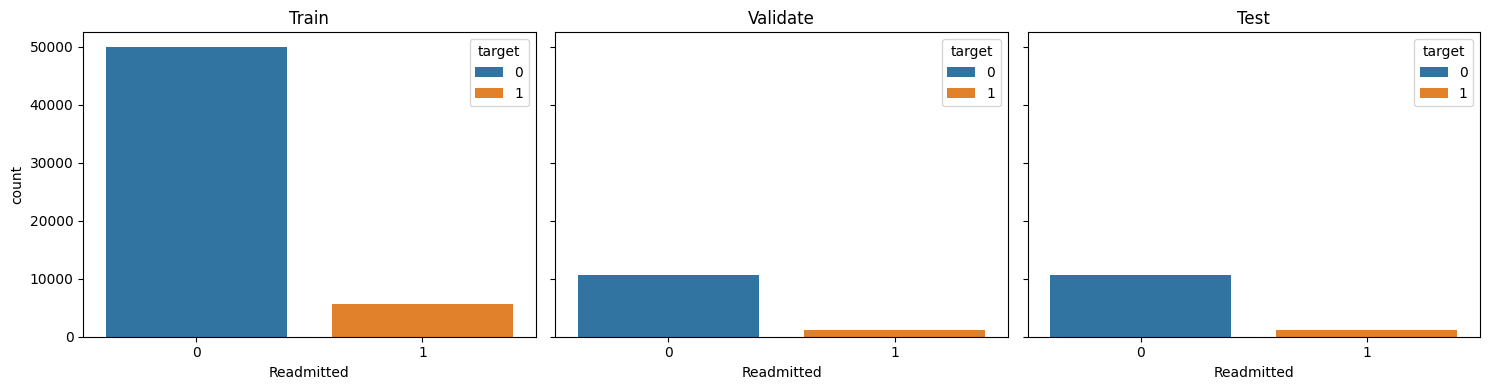

In [4]:
from shared_util.metrics.printing import check_y_dist

check_y_dist(
    y_train,
    y_validate,
    y_test
)

Reusable stratified k-fold builder

Preivously, we used 10 folds as per work from Liu, V.
However, increasing folds from 5 to 10 lead to creation of stratified group folds with only a single target variable and missing columns (due to missing one hot encoded column data from sparse columns like medical specialty)

5 folds maintains a good bias reduction while reducing the chance of odd fold creation.



In [5]:

from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from shared_util.baseline import get_baseline_score, make_group_cv
from shared_util.pipeline import CleaningPipeline

Get a baseline before looking at feature importance or hyperparameter tuning

We can use this baseline to check class imbalance approach methods, as well as to get a sense if this model can learn anything from the engineered features

In [6]:
print('Baseline ROC_AUC using Undersampling')

roc_auc_m = get_baseline_score(
    RandomForestClassifier(random_state=42),
    RandomUnderSampler(random_state=42),
    X_train,
    y_train,
    preprocessor=CleaningPipeline(create_interactions=False)
    )

if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        model='rf',
        threshold_notes='base',
        data='train',
        pipeline_notes='under_sample',
        notes=METRIC_NOTES,
        roc_auc=roc_auc_m
    )



Baseline ROC_AUC using Undersampling
roc_auc score per fold:  [0.65356797 0.63498387 0.62444832 0.6530924  0.63172125]
mean roc_auc score:  0.6395627610240409
logged row: (0, rf, train, base, under_sample)


In [7]:
from imblearn.over_sampling import SMOTE

print('Baseline ROC_AUC using SMOTE')

roc_auc_m = get_baseline_score(
    RandomForestClassifier(random_state=42),
    SMOTE(random_state=42),
    X_train,
    y_train,
    preprocessor=CleaningPipeline(create_interactions=False)
    )


if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        model='rf',
        threshold_notes='base',
        data='train',
        pipeline_notes='SMOTE',
        notes=METRIC_NOTES,
        roc_auc=roc_auc_m
    )


Baseline ROC_AUC using SMOTE
roc_auc score per fold:  [0.59282264 0.59191842 0.5973333  0.60046198 0.58900303]
mean roc_auc score:  0.5943078745083152
logged row: (0, rf, train, base, SMOTE)


After several iterations of data cleaning tweaks, baseline SMOTE is performing significantly better with mean ROC of ~0.59

However the random under sampler still outperforms with a mean AUC_ROC of ~0.63

SMOTE performed worse than under sampling so we will stick with under sampling going forward

A mean ROC_AUC score of 0.630 implies that the model has learned something from the data so we will continue analysis.

In [8]:
# shared code
import matplotlib.pyplot as plt


def make_rf_pipe(create_interactions=False):
    _u = RandomUnderSampler(random_state=42)
    _rf = RandomForestClassifier(random_state=42)
    _cl = CleaningPipeline(create_interactions=create_interactions)
    return Pipeline(
        [
            ('preprocessor', _cl),
            ('under_sample', _u),
            ('model', _rf)
        ]
    )

def plot_feature_importance(df, col1, col2, size, title):
    plt.figure(figsize=(10,6))
    plt.barh(df[col1][:size][::-1], df[col2][:size][::-1])
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()



### Why prefer permutation importance here

- Tree impurity based importance is naturaly skewed to favor continuous features
- Permutation importance is model agnostic, is uneffected by the large class imbalance, and is not effected by the under sampling technique used

In [9]:
# Build cv for feature and perumation importance

from sklearn.inspection import permutation_importance
def _transform_through_inference_steps(pipe, X, model_step='model'):
    """
    Apply only transform-capable steps in a fitted imblearn Pipeline.
    Skip any sampler (fit_resample-only). Stop before the final estimator.
    """
    Xt = X
    for name, step in pipe.steps:
        if name == model_step:
            break
        # Skip samplers (no transform)
        if hasattr(step, "fit_resample"):
            continue
        if hasattr(step, "transform"):
            Xt = step.transform(Xt)
        else:
            # Non-sampler but also no transform? treat as passthrough
            pass
    return Xt

def cv_permutation_importance(
    pipe_factory, X, y, cv, groups=None,
    scoring="roc_auc", n_repeats=10, n_jobs=-1, random_state=42,
    model_step='model', prep_step='preprocessor'
):
    perm_means = []
    feat_names = None

    for tr_idx, va_idx in cv.split(X, y, groups):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

        pipe = pipe_factory()
        pipe.fit(X_tr, y_tr)

        # Transform validation through inference-capable steps
        Xt_va = _transform_through_inference_steps(pipe, X_va, model_step=model_step)

        # Get names from the preprocessor if available; otherwise fallback
        preproc = pipe.named_steps.get(prep_step)
        if hasattr(preproc, "get_feature_names_out"):
            feat_names_fold = np.asarray(preproc.get_feature_names_out(), dtype=object)
        else:
            feat_names_fold = np.array([f"x{i}" for i in range(Xt_va.shape[1])], dtype=object)

        if feat_names is None:
            feat_names = feat_names_fold
        else:
            if len(feat_names) != len(feat_names_fold):
                raise RuntimeError("Transformed feature count changed across folds; pipeline not schema-stable.")

        model = pipe.named_steps[model_step]

        r = permutation_importance(
            model, Xt_va, y_va,
            scoring=scoring, n_repeats=n_repeats,
            n_jobs=n_jobs, random_state=random_state
        )
        perm_means.append(r.importances_mean) #type: ignore

    arr = np.vstack(perm_means)
    df = pd.DataFrame({
        "feature": feat_names,
        "importance_mean": arr.mean(axis=0),
        "importance_std": arr.std(axis=0)
    }).sort_values("importance_mean", ascending=False)
    return df

### Permutation Importance of Features

                        feature  importance_mean  importance_std
6              number_inpatient         0.068666        0.007813
5              number_emergency         0.006262        0.001158
3               num_medications         0.005138        0.004613
1            num_lab_procedures         0.003696        0.002270
7              number_diagnoses         0.003604        0.003331
0              time_in_hospital         0.003514        0.003495
37     specialty_cat_cardiology         0.002296        0.000603
12  diag1_group_musculoskeletal         0.001726        0.000316
56               metformin_flag         0.001719        0.001398
51    admit_type_group_elective         0.001613        0.001074
2                num_procedures         0.001363        0.002611
57                 insulin_flag         0.001227        0.002906
36        discharge_loc_unknown         0.001209        0.000760
31      diag3_group_respiratory         0.001156        0.001278
47               a1c_grou

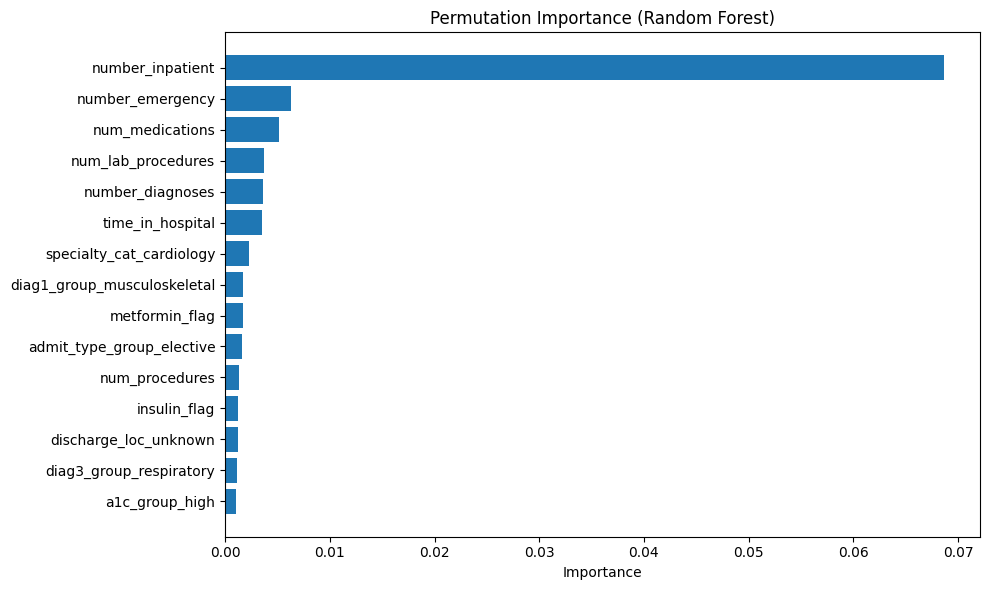

In [10]:
rf_perm_imp_df = cv_permutation_importance(
    make_rf_pipe, 
    X_train, 
    y_train, 
    make_group_cv(),
    groups=X_train['patient_nbr'] 
    )
print(rf_perm_imp_df.head(15))
plot_feature_importance(rf_perm_imp_df, 'feature', 'importance_mean', 15, 'Permutation Importance (Random Forest)')



Permutation importance reveals that the model is heavily leaning on the number of inpatient visits for its predictions.


,feature,importance_mean
1,num_lab_procedures,0.109265
3,num_medications,0.094541
0,time_in_hospital,0.069198
6,number_inpatient,0.063251
7,number_diagnoses,0.049011


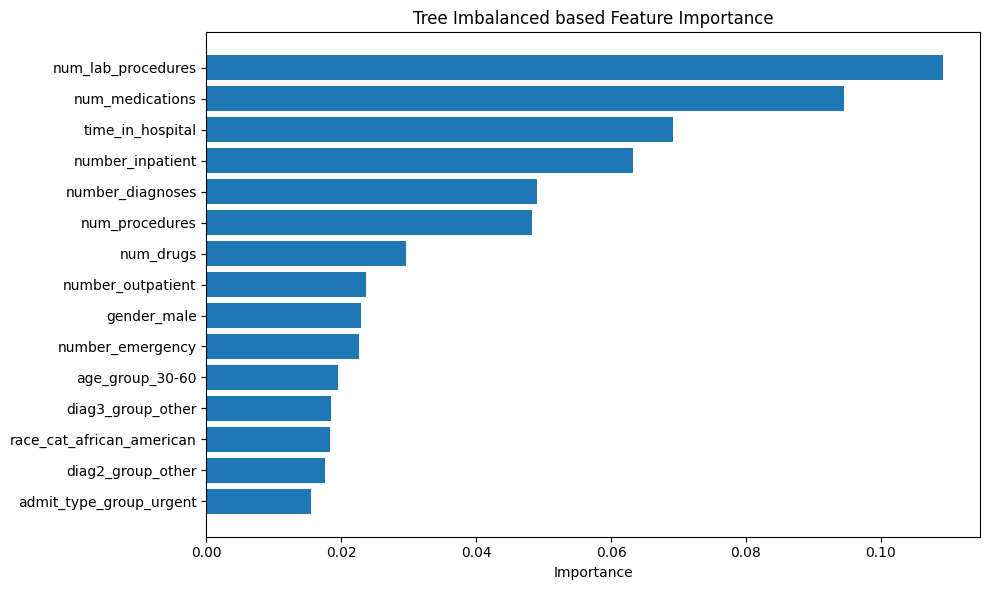

In [11]:
# dropping in a measure of feature importance given out of group context, not perfect but close enough for a general comparison

pipe = make_rf_pipe()


X_cleaned = CleaningPipeline(create_interactions=False, log_transform_cols=None).fit_transform(X_train)

X_cols = X_cleaned.columns #type: ignore

pipe.fit(X_train, y_train)


feat_imp_df = pd.DataFrame({
    'feature' : X_cols,
    'importance_mean' : (pipe.named_steps['model'].feature_importances_)
}).sort_values('importance_mean', ascending=False)

display(feat_imp_df.head(5))

plot_feature_importance(feat_imp_df, 'feature', 'importance_mean', 15, 'Tree Imbalanced based Feature Importance')


The above figure shows why we do not use the tree based feature importance, it heavily favors the contious columns, even if they have less impact on model outcomes.

<HR>

Analysis of feature importance aligns with previous literature and common sense thinking. The analysis suggests that the number of inpatient hospital visits in the patient's history is a leading factor in determining readmittance in the future.

Analysis also suggests discharges to other inpatient facilities is a strong indicator of readmittance risk.


<HR>

### Hyperparameter Search for Random Forest



In [12]:
from sklearn.model_selection import RandomizedSearchCV

def rf_search(X_train, y_train, create_interactions=False):

    pipe_h = make_rf_pipe(create_interactions=create_interactions)

    param_grid = {
        'model__n_estimators': [100, 200, 500],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2', 0.2, 0.5],
        'model__class_weight': [None, 'balanced'],
        'model__bootstrap': [True, False],
        'model__oob_score': [True, False]
    }

    rs = RandomizedSearchCV(
        estimator=pipe_h,
        param_distributions=param_grid,
        n_iter=30,
        scoring='roc_auc',
        cv=make_group_cv(),
        n_jobs=-1,
        random_state=42,
        refit=True
        )


    rs.fit(X_train, y_train, groups=X_train['patient_nbr'])

    print("Best ROC_AUC (cv):", rs.best_score_)
    print("Best params:", rs.best_params_)

    # Summarize top results
    res_df = pd.DataFrame(rs.cv_results_).sort_values('rank_test_score').reset_index(drop=True)
    res_df[['rank_test_score','mean_test_score','std_test_score','params']].head(10)

    return rs

In [13]:
from shared_util.metrics.printing import print_metrics

rs = rf_search(X_train, y_train)

# predict on held out val set
y_proba = rs.best_estimator_.predict_proba(X_validate)[:, 1] #type: ignore

y_pred = rs.best_estimator_.predict(X_validate) #type: ignore
# roc auc
print('Held Out Validate Metrics (Random Forest)')

print_metrics(y_validate, y_pred, y_proba,
              METRICS_DB_ID, 
              METRIC_NOTES, 
              model='rf',
              data='validate',
              hyperparam_notes="tuned_best_roc_auc",
              pipeline_notes='under_sample',
              log=LOG
              
)



Best ROC_AUC (cv): 0.6586582567087553
Best params: {'model__oob_score': True, 'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__class_weight': 'balanced', 'model__bootstrap': True}
Held Out Validate Metrics (Random Forest)
ROC_AUC:     0.6397471940562743
Accuracy:      0.6422388436003026
F1 score:      0.23805262215858242
Precision:     0.15186115551495774
Recall:        0.5504966887417219

Confusion matrix:

TN: 6977, FP: 3714, FN: 543, TP: 665

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.65      0.77     10691
           1       0.15      0.55      0.24      1208

    accuracy                           0.64     11899
   macro avg       0.54      0.60      0.50     11899
weighted avg       0.85      0.64      0.71     11899

logged row: (0, rf, validate, base, under_sample)


<HR>

The tuned random forest model initially displays decent class differentiation (ROC AUC = 0.71), but shows very poor Precision (0.16), and F1 (0.25) before threshold sweep.

The accuracy score is mostly meaningless due to high class imbalance.

The confusion matrix shows many false positives were predicted. 



Due to the nature of our business problem, we will align the model to attempt to maximize recall without sacrificing precision too much. This objective is due to the desire not to miss potential high risk patients while comparing the relatively low cost of having to spend extra time monitoring a patient who ends up without needing to be readmitted.

Best threshold (F2): 0.4402
Precision: 0.125  Recall: 0.776  F2: 0.380


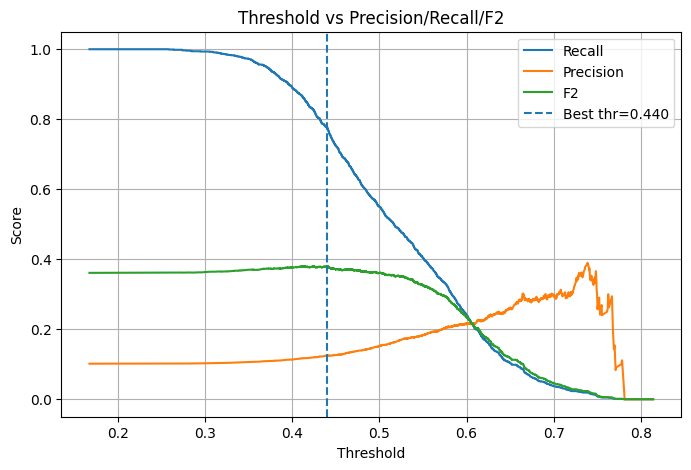

In [14]:
from shared_util.metrics.scoring import get_scores, best_threshold_by_fbeta, plot_scoring

rf_scores = get_scores(rs.best_estimator_, X_validate)
info = best_threshold_by_fbeta(y_validate, rf_scores)

best_thresh = info["threshold"]
y_pred_custom = (rf_scores >= best_thresh).astype(int)

print(f"Best threshold (F2): {best_thresh:.4f}")
print(f"Precision: {info['precision']:.3f}  Recall: {info['recall']:.3f}  F2: {info['fbeta']:.3f}")

plot_scoring(info['curve'])


In [15]:

rf_scores_test = get_scores(rs.best_estimator_, X_test)

y_pred_custom_test = (rf_scores_test >= best_thresh).astype(int)



print_metrics(y_test, y_pred_custom_test, y_proba=rf_scores_test,
              metrics_db_id=METRICS_DB_ID, 
              metrics_notes=METRIC_NOTES,
              data='test',
              threshold_notes='f2_weighted',
              model='rf',
              hyperparam_notes='tuned_best_roc_auc',
              pipeline_notes='under_sample',
              log=LOG
              )

ROC_AUC:     0.6775471374800355
Accuracy:      0.4333136244615255
F1 score:      0.21504621504621504
Precision:     0.12425635478637101
Recall:        0.7984361424847958

Confusion matrix:

TN: 4211, FP: 6477, FN: 232, TP: 919

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.39      0.56     10688
           1       0.12      0.80      0.22      1151

    accuracy                           0.43     11839
   macro avg       0.54      0.60      0.39     11839
weighted avg       0.87      0.43      0.52     11839

logged row: (0, rf, test, f2_weighted, under_sample)


By tuning the threshold we raised positive class recall to 0.69 while maintaining a 0.15 precision (low but almost unchanged from previous test)

In practice, this may be acceptable, likely it would depend on the increased monitoring costs for patients that are selected vs. costs saved on catching signs of required readmission earlier. 

The model has a very high rate of false positives which would require additional monitoring. However, the model has very few false negatives which means very few high-risk patients would be left un-monitored leading to the best patient outcomes at the cost of increased healthcare costs.

## Tuned RF model with interaction features

In [16]:
METRICS_NOTES = 'with interaction terms'


In [17]:
rs_int = rf_search(X_train, y_train, create_interactions=True)


Best ROC_AUC (cv): 0.6582527768761887
Best params: {'model__oob_score': True, 'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 0.2, 'model__max_depth': 10, 'model__class_weight': 'balanced', 'model__bootstrap': True}


In [18]:


rf_int_pred = rs_int.best_estimator_.predict(X_validate) # type: ignore
rf_int_proba = rs_int.best_estimator_.predict_proba(X_validate)[:, 1]  #type: ignore


print_metrics(y_validate, rf_int_pred, y_proba=rf_int_proba,
              metrics_db_id=METRICS_DB_ID, 
              metrics_notes=METRIC_NOTES,
              data='validate',
              threshold_notes='base',
              model='rf+int',
              hyperparam_notes='tuned_best_roc_auc',
              pipeline_notes='under_sample',
              log=LOG
              )


ROC_AUC:     0.6407613849861956
Accuracy:      0.6531641314396168
F1 score:      0.23870134661501569
Precision:     0.153572276287681
Recall:        0.5355960264900662

Confusion matrix:

TN: 7125, FP: 3566, FN: 561, TP: 647

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.67      0.78     10691
           1       0.15      0.54      0.24      1208

    accuracy                           0.65     11899
   macro avg       0.54      0.60      0.51     11899
weighted avg       0.85      0.65      0.72     11899

logged row: (0, rf+int, validate, base, under_sample)


The model trained with the interaction terms whos no noticable change in performance which is expected for a tree based model.

Perviously at this step, I noticed a large uptick in performance after adding the interaction terms, and discoved several issues with my data pipeline:

- Missing data \
My data import method (pip package copy pasted from the uci.edu webpage) did not contain patient number of encounter id columns. After reading the original study paper by Strack et al., I had made the assumption that this step (handling repeated patient encounters) was already handled when it was not.

This caused my model to have duplicate patient records across training/validation/test sets


- Incorrectly One hot encoded values \
My global data processing pipeline created several potential data leakage points when one hot encoding categorical variables globally instead of post split.

This was not noticable with the full validation/test sizes but was definitely causing insues inside the smaller folds in the cross validation pipelines

In [ ]:
if LOG:
    metrics_db.close(write=True) # remove the db dataframe from memory to prevent weirdness when running multiple notebooks